## Create function that loads in one 8-day average of MODIS data and plots chla in our study region

In [2]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask

## Reading in .csv and adding season/datetime

In [4]:
df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_32468/3120791858.py:1: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')


In [17]:
# NEW DATA

#convert to datetime
df_new['DATE'] = pd.to_datetime(df_new['DATE'],format = 'mixed')
df_new = df_new.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon 

#fix lat lon values with '--' (replace with nan) 
df_new['LATITUDE'] = pd.to_numeric(df_new['LATITUDE'], errors='coerce')
df_new['LONGITUDE'] = pd.to_numeric(df_new['LONGITUDE'], errors='coerce')


NameError: name 'df_new' is not defined

In [6]:
#create season columns
df_new["year"] = df_new["DATE"].dt.year.astype("Int64")
df_new["month"] = df_new["DATE"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

df_new["season"] = df_new.apply(assign_season, axis=1)

## Login to earthaccess

In [3]:
auth = earthaccess.login()

Enter your Earthdata Login username:  walkersl
Enter your Earthdata password:  ········


## Search for MODIS data from 2014-2015 in study region

In [28]:
results = earthaccess.search_datasets(instrument="MODIS")

In [29]:
for item in results:
    summary = item.summary()
    print(summary["short-name"])

CIESIN_SEDAC_USPAT_USUEXT2015
Sat_ActiveLayer_Thickness_Maps_1760
ABoVE_MODIS_MAIAC_Reflectance_1858
Wildfires_NWT_Canada_1548
Wildfires_2014_NWT_Canada_1307
Burned_Area_Depth_AK_CA_2063
MODIS_MAIAC_Reflectance_1700
Dall_Sheep_Population_Dynamics_1640
Dall_Sheep_Snowpack_1602
Effect_Environment_Moose_1739
ABoVE_Frac_Open_Water_1362
Snow_Cover_Extent_and_Depth_1757
BurnedArea_Emissions_AK_YT_NWT_1812
Last_Day_Spring_Snow_1528
GPP_MODIS_Alaska_Canada_2024
MODIS_CCaN_NDVI_Trends_Alaska_1666
Albedo_Boreal_North_America_1605
Alaska_Yukon_NDVI_1614
NorthSlope_NEE_TVPRM_1920
Wildfires_Date_of_Burning_1559
Wolves_Denning_Pups_Climate_1846
AGB_Pantropics_Amazon_Mexico_1824
ACTIVATE-MODIS-MERRA2
ADAM.Surface.Reflectance.Database
CIESIN_AfSIS_MODIS_ALB2012
CIESIN_AfSIS_MODIS_LCT2012
CIESIN_AfSIS_MODIS_LST201404
CIESIN_AfSIS_MODIS_LAIFPAR2012
CIESIN_AfSIS_MODIS_PP2012
CIESIN_AfSIS_MODIS_VEGIN201404
aad_ais_gz_modis_slope_break
AMDBLWV
AMDBLWV
AMMBLWV
AMMBLWV
NSIDC-0432
UNIZH_AGREG
CIESIN_SEDAC_SDE

/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_64775/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_64775/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_64775/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_64775/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `Da

In [30]:
tspan = ("2015-01-01", "2015-01-31")
bbox = (150, -78, 160, -50)
# bbox = (155, -65, 160, -60) # west, south, east, north 
clouds = (0, 25)
# cloud_cover=clouds

In [31]:
results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    temporal=tspan,
    bounding_box=bbox,
    granule_name="*.8D.*4*",  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)
)
len(results)

/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


4

In [32]:
results

/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/results.py:364: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  Size(MB): {self.size()}


[Collection: {'ShortName': 'MODISA_L3m_CHL', 'Version': '2022.0'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'NorthBoundingCoordinate': 90, 'SouthBoundingCoordinate': -90, 'EastBoundingCoordinate': 180, 'WestBoundingCoordinate': -180}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2015-01-01T00:00:00Z', 'EndingDateTime': '2015-01-08T23:59:59Z'}}
 Size(MB): 42.66191005706787
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20150101_20150108.L3m.8D.CHL.chlor_a.4km.nc'],
 Collection: {'Version': '2022.0', 'ShortName': 'MODISA_L3m_CHL'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'NorthBoundingCoordinate': 90, 'EastBoundingCoordinate': 180, 'SouthBoundingCoordinate': -90, 'WestBoundingCoordinate': -180}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2015-01-09T00:00:00Z', 'EndingDateTime': '2015-01-16T23:59:59Z'}}
 Size(MB): 43.22428894

## Opening files without downloading them (streaming them)

In [33]:
paths = earthaccess.open(results)

/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

In [34]:
paths[3]

<File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20150125_20150201.L3m.8D.CHL.chlor_a.4km.nc>

In [9]:
dataset = xr.open_dataset(paths[1])
datatree = xr.open_datatree(paths[1])
dataset = xr.merge(datatree.to_dict().values())

data_chla = dataset['chlor_a'].sel(lon = slice(150,180),
                           lat = slice(-55,-70))

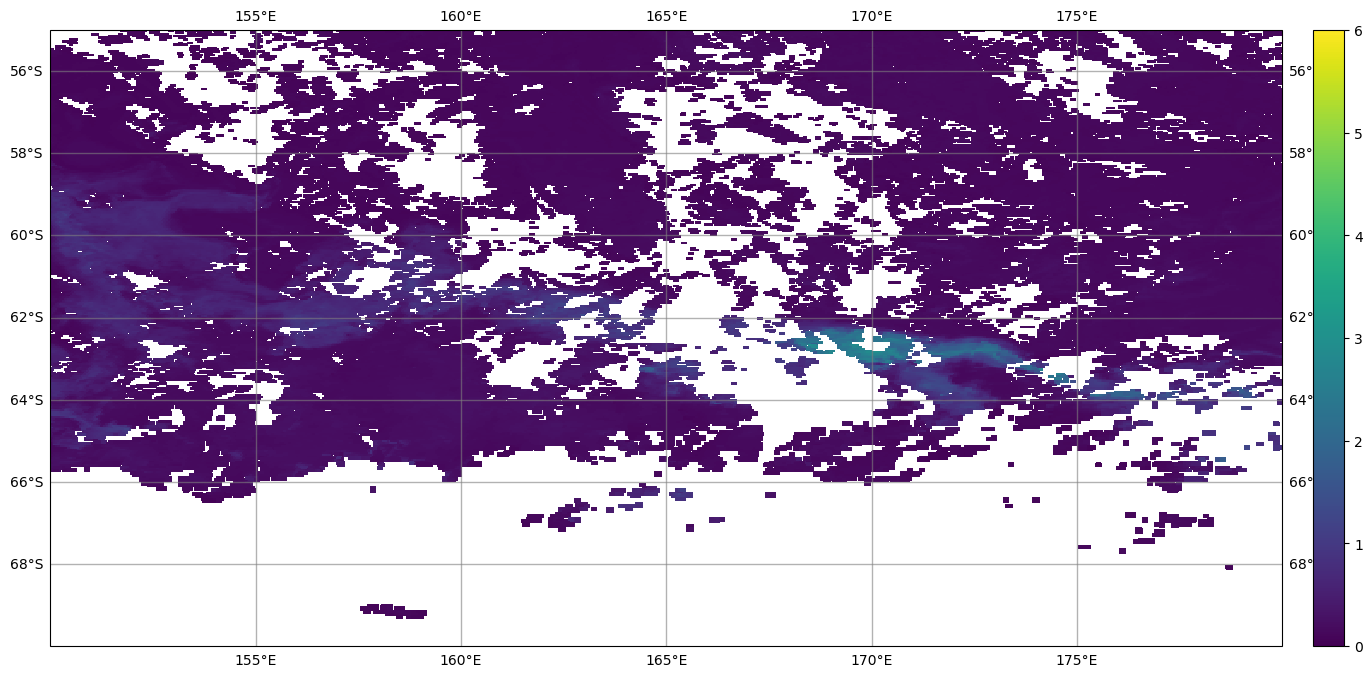

In [10]:
# PLOTTING DATA ------------------------------------------------
#assign projection type
crs0 = ccrs.PlateCarree()


#create figure object
fig = plt.figure(figsize = (20,8))

#RECCAP regions panel
ax = fig.add_subplot(111, projection = crs0)

#Colormap specification
color = cmocean.cm.haline

plot = plt.pcolor(data_chla['lon'],data_chla['lat'],data_chla,
             vmin = 0,vmax = 6) 

cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
# cbar.ax.tick_params(labelsize=tick_size)
# cbar.set_label('Chla', size=axis_size)

gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')
    

## Testing function with same code as the error cell and it works fine

/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

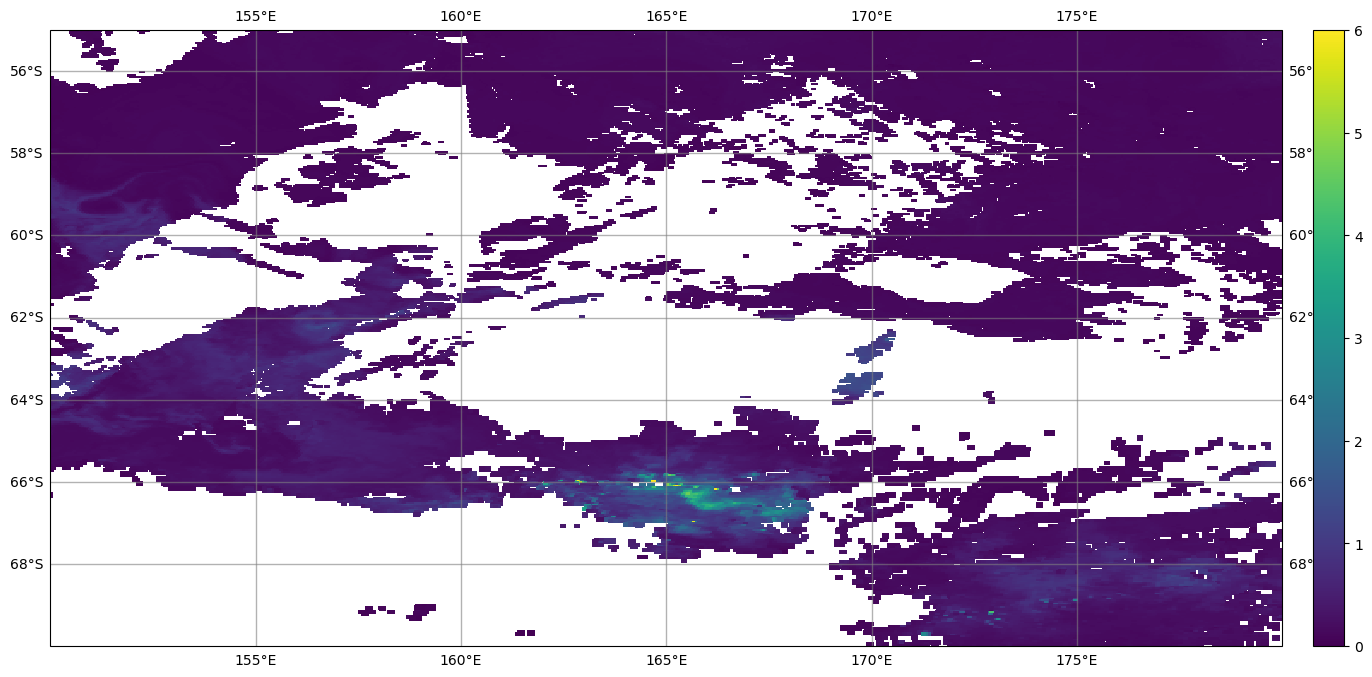

In [11]:
results = earthaccess.search_datasets(instrument="MODIS")

tspan = ("2015-01-01", "2015-01-31")
bbox = (150, -78, 160, -50)
# bbox = (155, -65, 160, -60) # west, south, east, north 
clouds = (0, 25)
# cloud_cover=clouds

results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    temporal=tspan,
    bounding_box=bbox,
    granule_name="*.8D.*4*",  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)
)

paths = earthaccess.open(results)

dataset = xr.open_dataset(paths[3])
datatree = xr.open_datatree(paths[3])
dataset = xr.merge(datatree.to_dict().values())

data_chla = dataset['chlor_a'].sel(lon = slice(150,180),
                           lat = slice(-55,-70))

# PLOTTING DATA ------------------------------------------------
#assign projection type
crs0 = ccrs.PlateCarree()

#create figure object
fig = plt.figure(figsize = (20,8))

#RECCAP regions panel
ax = fig.add_subplot(111, projection = crs0)

#Colormap specification
color = cmocean.cm.haline

plot = plt.pcolor(data_chla['lon'],data_chla['lat'],data_chla,
             vmin = 0,vmax = 6) 

cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
# cbar.ax.tick_params(labelsize=tick_size)
# cbar.set_label('Chla', size=axis_size)

gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')
    

In [43]:
results = earthaccess.search_datasets(instrument="MODIS")

tspan = ("2015-01-01", "2015-01-31")
bbox = (150, -78, 160, -50)
# bbox = (155, -65, 160, -60) # west, south, east, north 
clouds = (0, 25)
# cloud_cover=clouds

results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    temporal=tspan,
    bounding_box=bbox,
    granule_name="*.8D.*4*",  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)
)

paths = earthaccess.open(results)

dataset = xr.open_dataset(paths[3])
datatree = xr.open_datatree(paths[3])
dataset = xr.merge(datatree.to_dict().values())

data_chla = dataset['chlor_a'].sel(lon = slice(150,180),
                           lat = slice(-55,-70))


QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 918.24it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:01<00:00,  3.03it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 24966.10it/s]


In [50]:
dataset

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/62)
    product_name:                     AQUA_MODIS.20150125_20150201.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Standard Mapped Image
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    cdm_data_type:                    grid
    keywords:                         Earth Science > Oceans > Ocean Chemistr...
    keywords_vocabulary:              NASA Global Change Master Directory (GC...
    data_bins:                        14076931
    data_minimum:                     0.0019096292
    data_maximum:                     86.16353

In [54]:
title = getattr(dataset, 'time_coverage_start')
title

'2015-01-25T00:00:01.000Z'

In [26]:
data_chla

<xarray.DataArray 'chlor_a' (lat: 360, lon: 720)> Size: 1MB
array([[     nan,      nan,      nan, ..., 0.218481, 0.214592, 0.213257],
       [     nan,      nan,      nan, ..., 0.231031, 0.221565, 0.218345],
       [     nan,      nan,      nan, ..., 0.229509, 0.227859, 0.227303],
       ...,
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 1kB -55.02 -55.06 -55.1 ... -69.9 -69.94 -69.98
  * lon      (lon) float32 3kB 150.0 150.1 150.1 150.1 ... 179.9 179.9 180.0
Attributes:
    long_name:      Chlorophyll Concentration, OCI Algorithm
    units:          mg m^-3
    standard_name:  mass_concentration_of_chlorophyll_in_sea_water
    valid_min:      0.001
    valid_max:      100.0
    reference:      Hu, C., Lee Z., and Franz, B.A. (2012). Chlorophyll-a alg...
    display_scale:  log
    display_min:    0.01
    display_max:    20.0

## Function

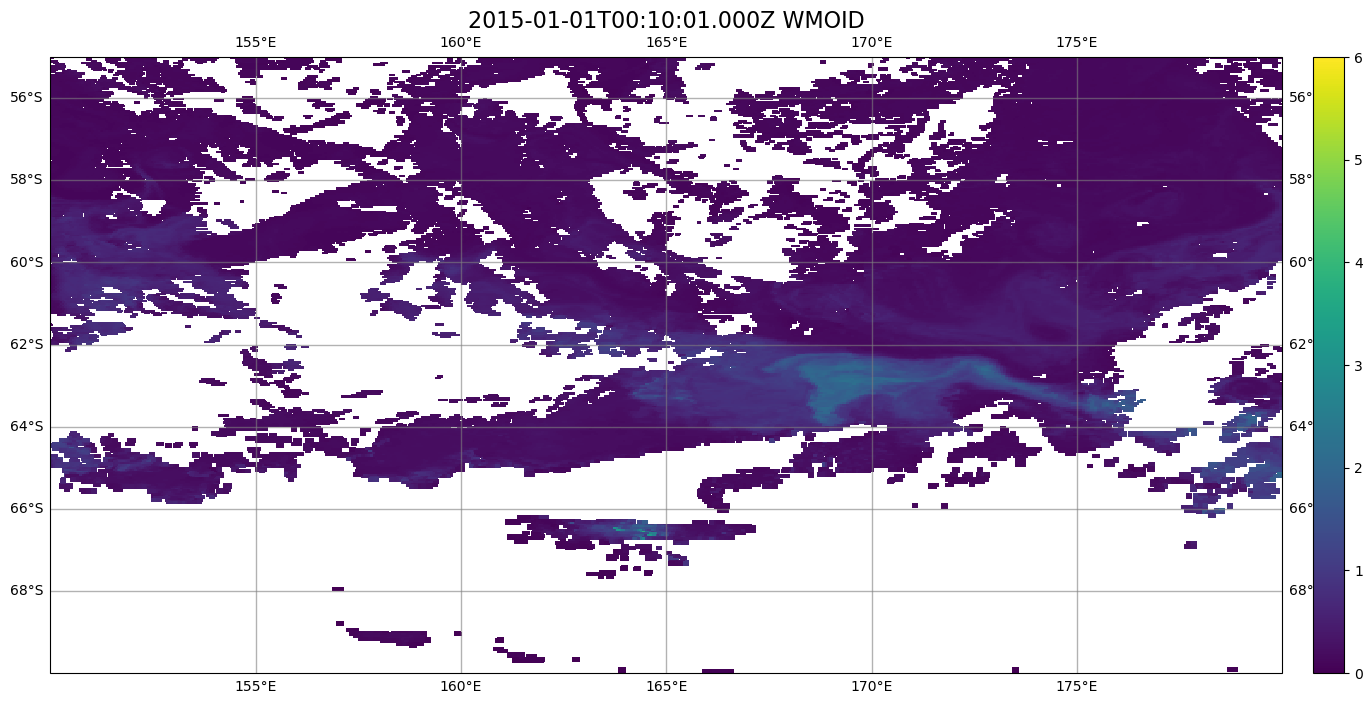

In [12]:
def sat_data(path, instrument, tspan, bbox, clouds, short_name="MODISA_L3m_CHL", granule_name, title):

    results = earthaccess.search_datasets(instrument="MODIS")
    
    # getting data files
    results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
    granule_name="*.8D.*4*")  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)
    
    
    # open files without downloading them
    paths = earthaccess.open(results)
    
    dataset = xr.open_dataset(path)
    datatree = xr.open_datatree(path)
    dataset = xr.merge(datatree.to_dict().values())

    data_chla = dataset['chlor_a'].sel(lon = slice(150,180),
                               lat = slice(-55,-70))


    # PLOTTING DATA ------------------------------------------------
    #assign projection type
    crs0 = ccrs.PlateCarree()
   

    #create figure object
    fig = plt.figure(figsize = (20,8))

    #RECCAP regions panel
    ax = fig.add_subplot(111, projection = crs0)

    #Colormap specification
    color = cmocean.cm.haline

    plot = plt.pcolor(data_chla['lon'],data_chla['lat'],data_chla,
                 vmin = 0,vmax = 6) 

    cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
    # cbar.ax.tick_params(labelsize=tick_size)
    # cbar.set_label('Chla', size=axis_size)

    gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')

    title = getattr(dataset, 'time_coverage_start')
    
    ax.set_title(title+' '+'WMOID', fontsize=16)
    
    
sat_data(path=paths[0], instrument="MODIS", tspan=("2015-01-01", "2015-01-31"), bbox=(150, -78, 160, -55), clouds=(0, 25), short_name="MODISA_L3m_CHL", granule_name="*.8D.*4*", title="getting there")

## Everything after this cell is workshopping things, not part of the final code

In [23]:
len(results)

4

## For loop testing: stops working when "results" chunk of code is put in the function above the for loop or in the same cell outside of the function

/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

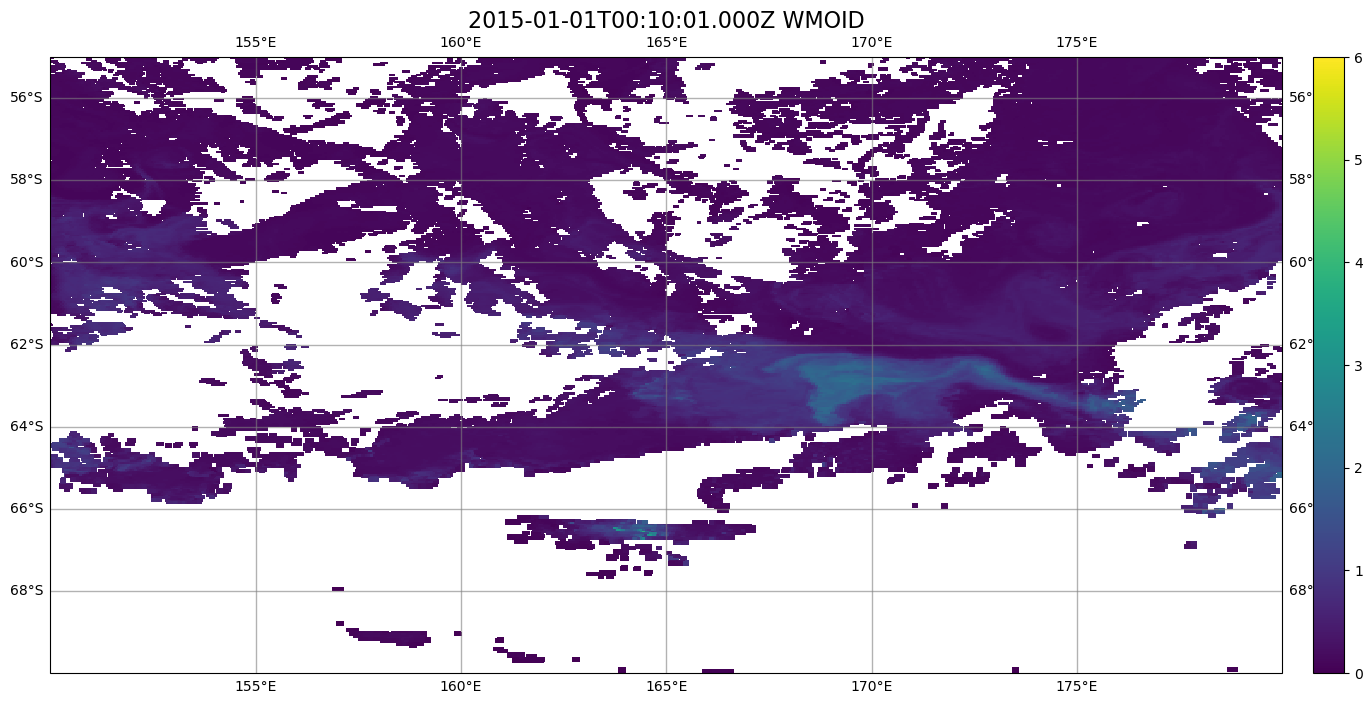

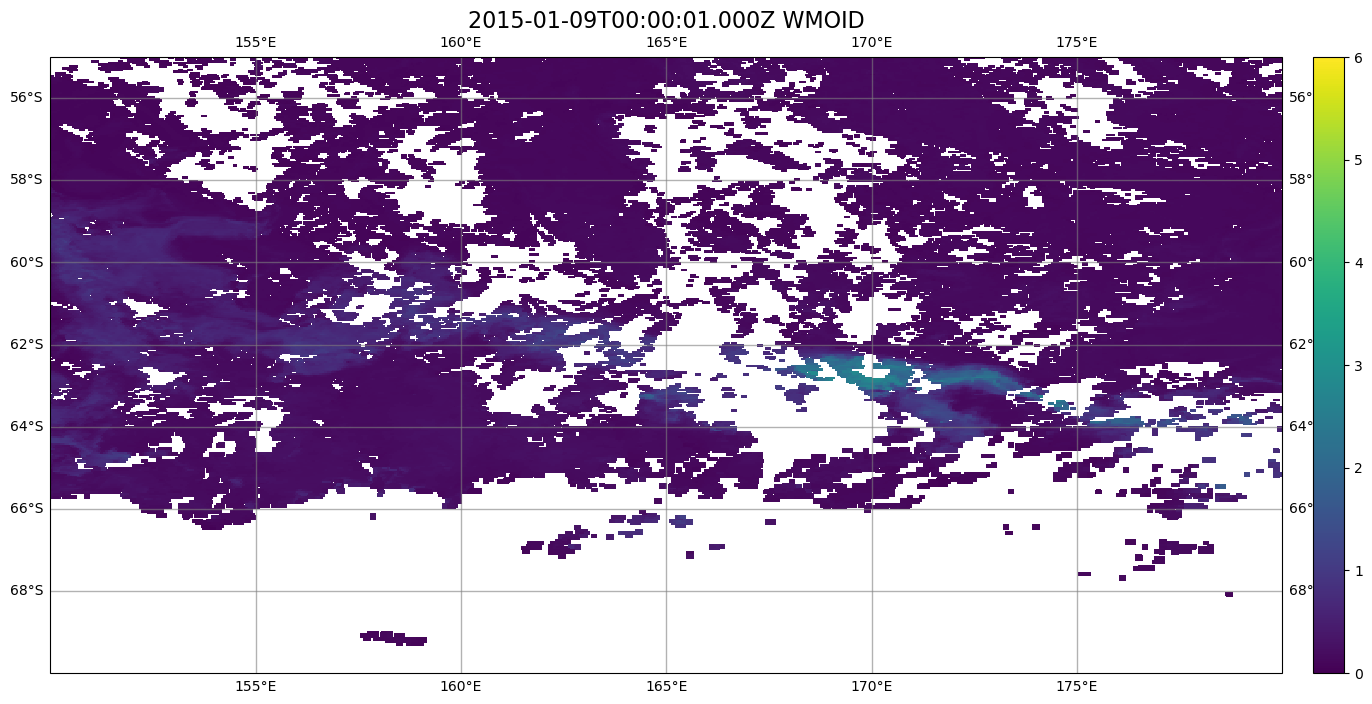

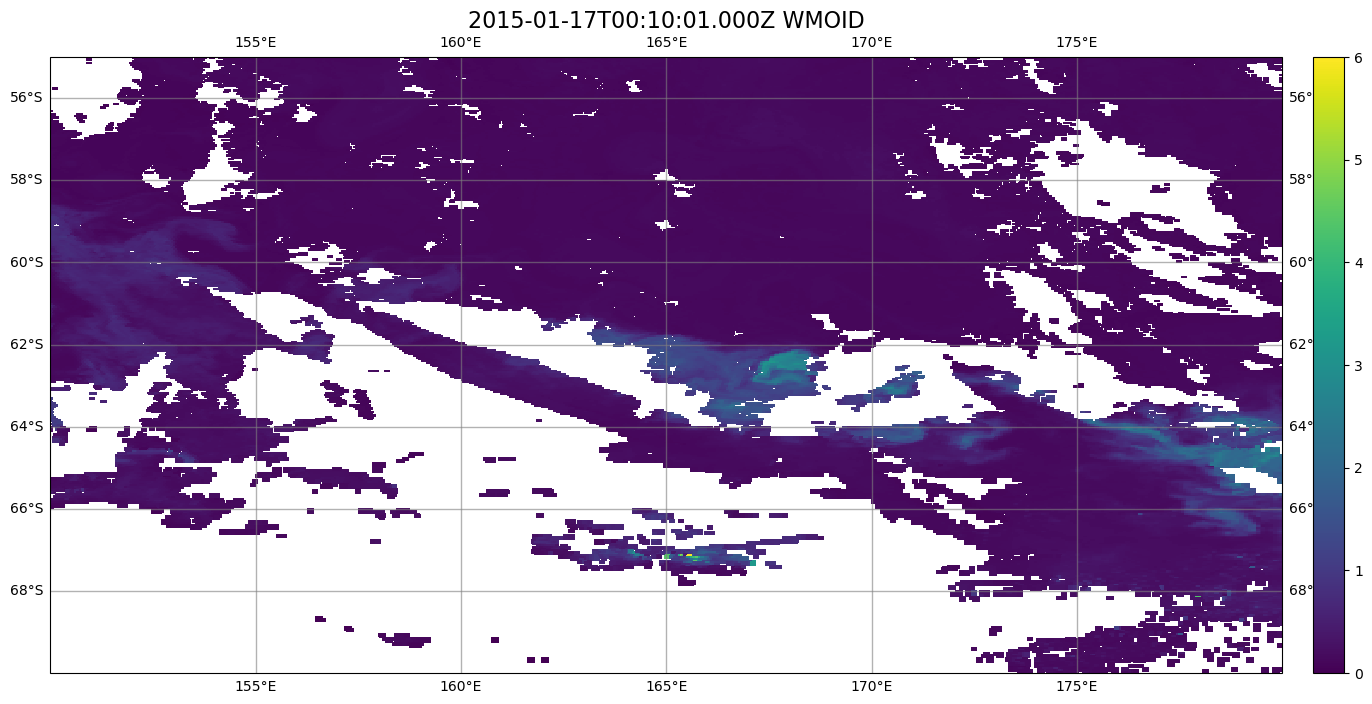

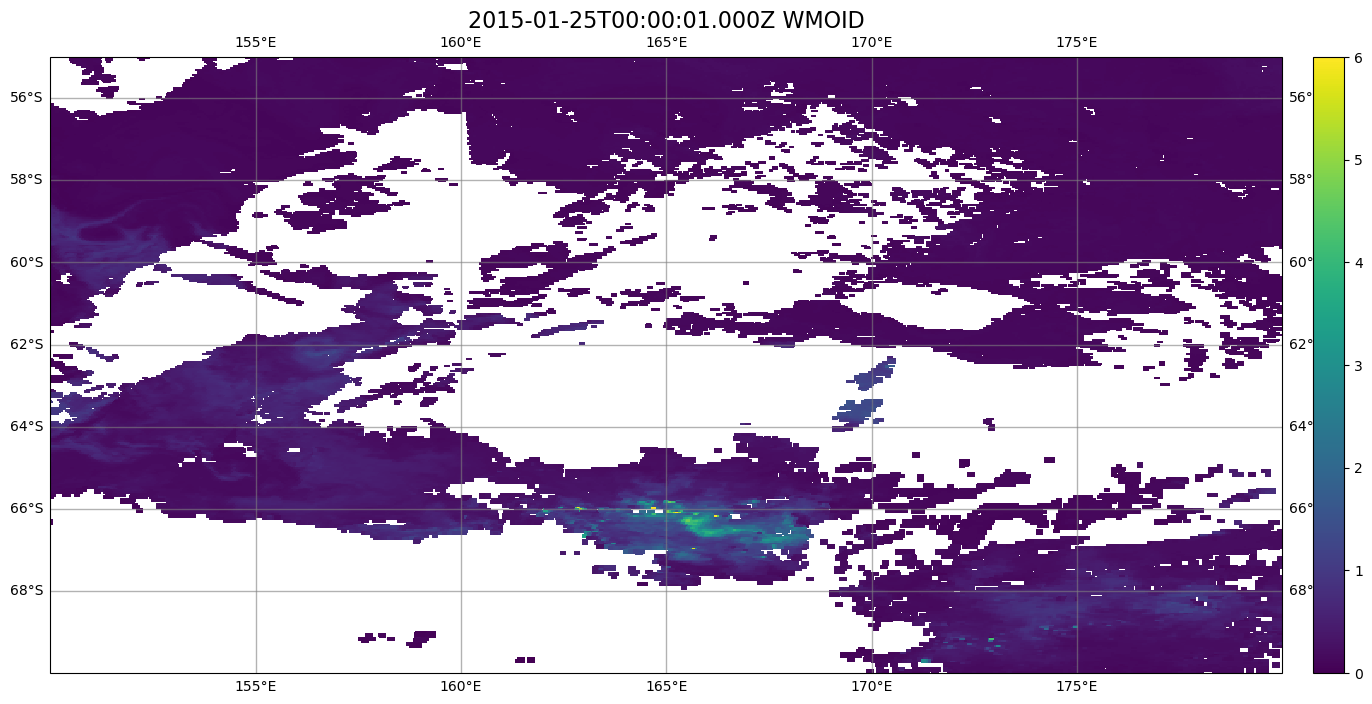

In [24]:
def test(sat_data):

    paths = earthaccess.open(results) #putting code outside of the loop that you don't need to run everytime

    for i in range(len(paths)):

        dataset = xr.open_dataset(paths[i])
        datatree = xr.open_datatree(paths[i])
        dataset = xr.merge(datatree.to_dict().values())
    
        data_chla = dataset['chlor_a'].sel(lon = slice(150,180),
                                   lat = slice(-55,-70))
    
    
        # PLOTTING DATA ------------------------------------------------
        #assign projection type
        crs0 = ccrs.PlateCarree()
           
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
    
        plot = plt.pcolor(data_chla['lon'],data_chla['lat'],data_chla,
                     vmin = 0,vmax = 3) 
    
        cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
        # cbar.ax.tick_params(labelsize=tick_size)
        # cbar.set_label('Chla', size=axis_size)
    
        gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                              linewidth=1, color='gray', alpha=0.6, linestyle='-')
    
        title = getattr(dataset, 'time_coverage_start')
        
        ax.set_title(title+' '+'WMOID', fontsize=16)
            
    plt.show()

test(sat_data = results)

In [6]:
# version edited by Stevie on 7/23/26
def chla_plot_matchups(shortname, tspan, bbox, clouds, granulename):

    # getting data files
    results = earthaccess.search_data(
        short_name=shortname,
        temporal=tspan,
        bounding_box=bbox,
        granule_name=granulename)  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)

    #open results (outside of the loop because you don't have to repeat this every time)
    paths = earthaccess.open(results)

    for i in tqdm(range(len(paths))):

        #open the granule and subset data to aar region
        ds = xr.open_dataset(paths[i],decode_times=False)
        data = ds['chlor_a'].sel(lon=slice(150, 180), lat=slice(-55,-70))

        # extract the start and end times, convert to datetime64 format
        time_start = getattr(ds, "time_coverage_start")
        time_end = getattr(ds, "time_coverage_end")
        time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
        time_end = pd.to_datetime(time_end, utc=True)
        
        # ^^ HINT: time_start and time_end are what you'll want to use for subsetting the Argo csv file to the correct date range
        # this is where you'll want to subset the Argo profile data

        # PLOTTING DATA ------------------------------------------------
        #assign projection type
        crs0 = ccrs.PlateCarree()
       
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
        # plot satellite data
        plot = ax.pcolormesh(data['lon'],data['lat'],data,cmap=color,
                     transform=crs0,norm=LogNorm(vmin=0.1, vmax=6)) 

        #add plotting the argo data here
        
        cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
        cbar.set_label('Log Chl-a (mg m$^{-3}$)')
        cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
        cbar.formatter = FormatStrFormatter("%.1f")
        cbar.update_ticks()
        # cbar.ax.tick_params(labelsize=tick_size)
        # cbar.set_label('Chla', size=axis_size)
        gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                              linewidth=1, color='gray', alpha=0.6, linestyle='-')

        # create string for the title label
        title_start = time_start.strftime("%Y-%m-%d")
        title_end = time_end.strftime("%Y-%m-%d")
        
        ax.set_title('MODIS '+title_start+' to '+title_end, fontsize=16)        
        
        #save figure
        fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_MODIS_float_matchup.png',
                bbox_inches='tight')
        plt.close()
   
chla_plot_matchups(shortname="MODISA_L3m_CHL",
                   tspan=("2015-01-01", "2015-01-31"), 
                   bbox=(150, -78, 180, -50), 
                   clouds=None, 
                   granulename="*.8D.*4*")


/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/steviewalker/anaconda3/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:13<00:00,  3.32s/it]


## This cell is crashing my kernel everytime I run it in or out of the function

In [ ]:
# Opening files into xarrays and merging variables into one
dataset = xr.open_dataset(paths[0])
datatree = xr.open_datatree(paths[0])
dataset = xr.merge(datatree.to_dict().values())
dataarray = dataset.to_dataarray(dataset)


In [10]:
dataset = xr.open_dataset(paths[0])

In [11]:
datatree = xr.open_datatree(paths[0])

In [12]:
dataset = xr.merge(datatree.to_dict().values())

## The culprit has been found

In [ ]:
dataarray = dataset.to_dataarray(dataset)

## Trying ways around changing dataset to dataarray

In [14]:
dataset

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/62)
    product_name:                     AQUA_MODIS.20150101_20150108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Standard Mapped Image
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    cdm_data_type:                    grid
    keywords:                         Earth Science > Oceans > Ocean Chemistr...
    keywords_vocabulary:              NASA Global Change Master Directory (GC...
    data_bins:                        13111149
    data_minimum:                     0.001
    data_maximum:                     86.01173

In [18]:
data_chla = dataset['chlor_a'].sel(lon = slice(150,180),
                               lat = slice(-55,-70))

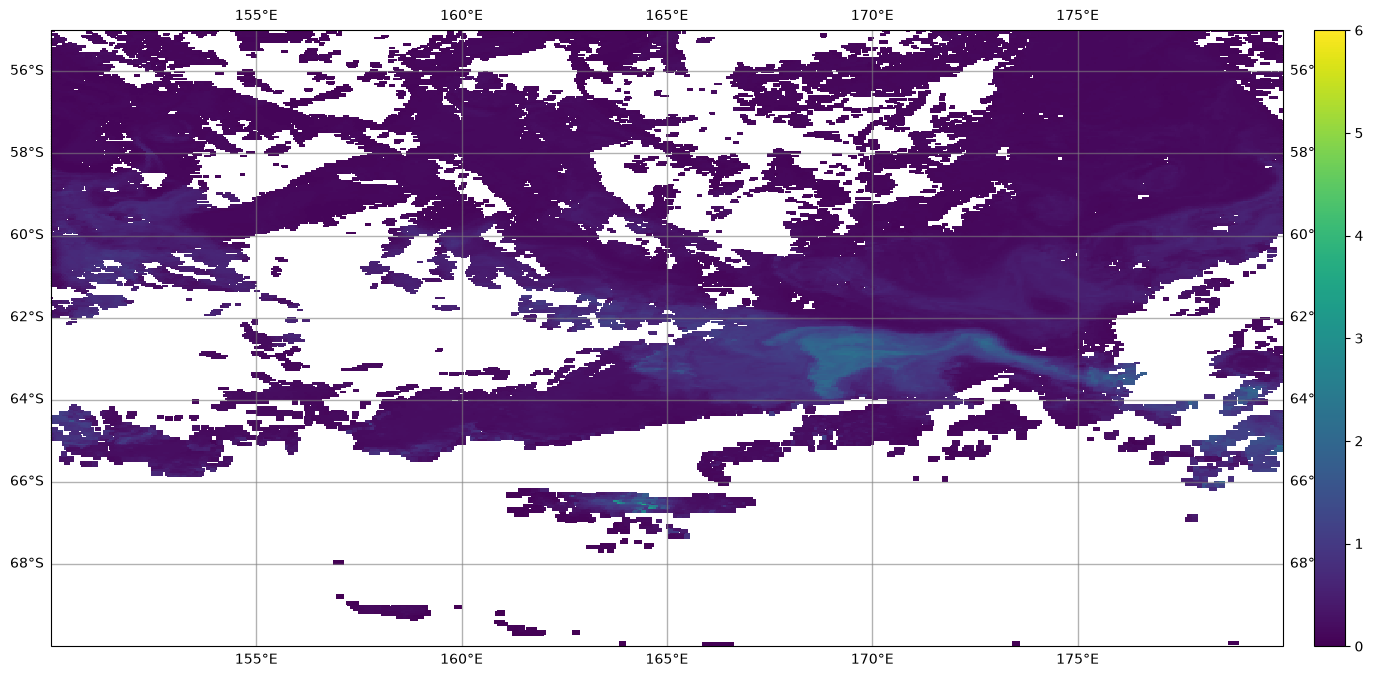

In [19]:
def sat_plot(data):

 # PLOTTING DATA ------------------------------------------------
    #assign projection type
    crs0 = ccrs.PlateCarree()
   

    #create figure object
    fig = plt.figure(figsize = (20,8))

    #RECCAP regions panel
    ax = fig.add_subplot(111, projection = crs0)

    #Colormap specification
    color = cmocean.cm.haline

    plot = plt.pcolor(data['lon'],data['lat'],data,
                 vmin = 0,vmax = 6) 

    cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
    # cbar.ax.tick_params(labelsize=tick_size)
    # cbar.set_label('Chla', size=axis_size)

    gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')

sat_plot(data=data_chla)